<a href="https://colab.research.google.com/github/R12-l/2023-Java-creando-tu-primera-aplicacion/blob/aula-1/TC%20filtro%20pasa%20bajas%2C%20pasa%20altas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pydicom

In [ ]:
!pip install dicom2nifti

In [ ]:
import dicom2nifti
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pydicom

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
dicom_file = pydicom.dcmread('/content/drive/MyDrive/Colab Notebooks/ID_0001_AGE_0069_CONTRAST_1_CT.dcm')

In [ ]:
print(dicom_file)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 194
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: CT Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.184912220734460823585918206046
(0002,0010) Transfer Syntax UID                 UI: Implicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.2.40.0.13.1.1.1
(0002,0013) Implementation Version Name         SH: 'dcm4che-1.4.31'
-------------------------------------------------
(0008,0000) Group Length                        UL: 422
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'AXIAL']
(0008,0016) SOP Class UID                       UI: CT Image Storage
(0008,0018) SOP Instance UID                    UI: 1.3.6.1.4.1.14519.5.2.1.7777.9002.1849122207344608

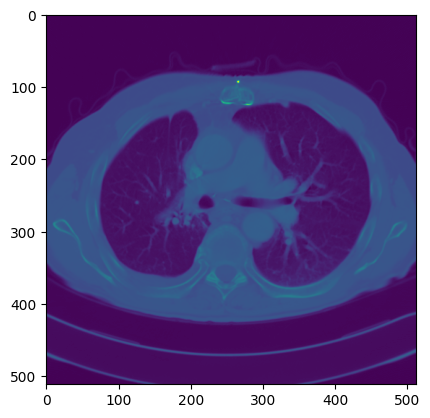

In [ ]:
ct = dicom_file.pixel_array
plt.figure()
plt.imshow(ct)

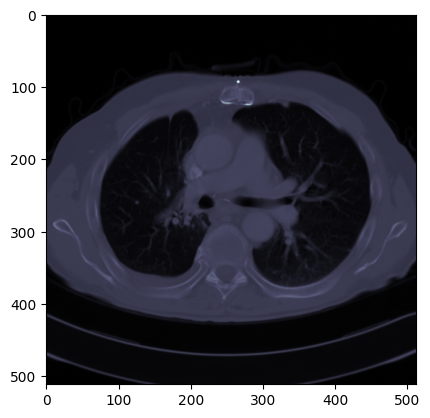

In [ ]:
plt.figure()
plt.imshow(ct, cmap='bone')

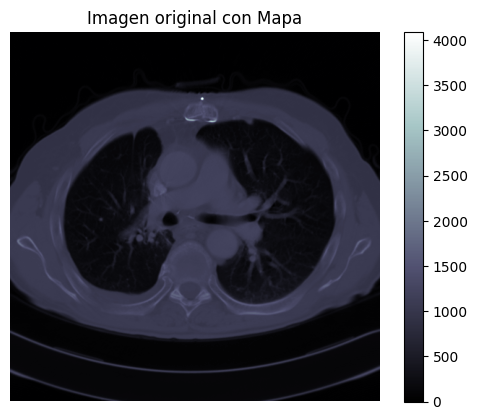

In [ ]:
plt.figure()
plt.imshow(ct, cmap = 'bone')
plt.colorbar()
plt.title("Imagen original con Mapa")
plt.axis('off')
plt.show()

In [ ]:
# Filtro Gaussiano
import cv2

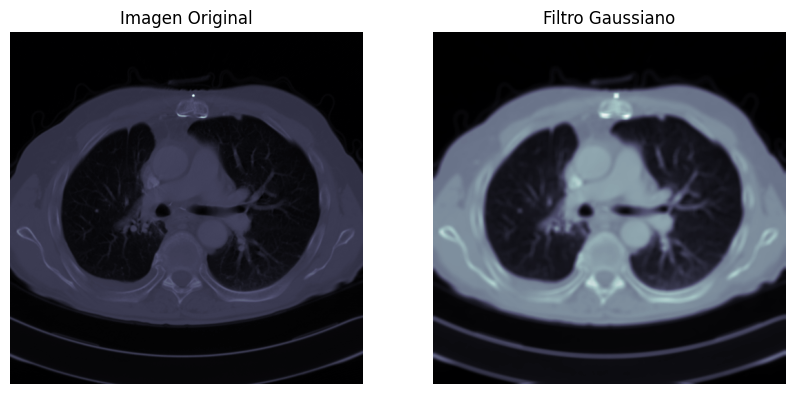

In [ ]:
# Aplicar Filtro Gaussiano
gaussian_filtered = cv2.GaussianBlur(ct, (7,7), sigmaX = 7)

# Visualización
plt.figure(figsize = (10, 5))
plt.subplot(1, 2, 1)
plt.imshow(ct, cmap = 'bone')
plt.title("Imagen Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(gaussian_filtered, cmap = 'bone')
plt.title("Filtro Gaussiano")
plt.axis('off')
plt.show()

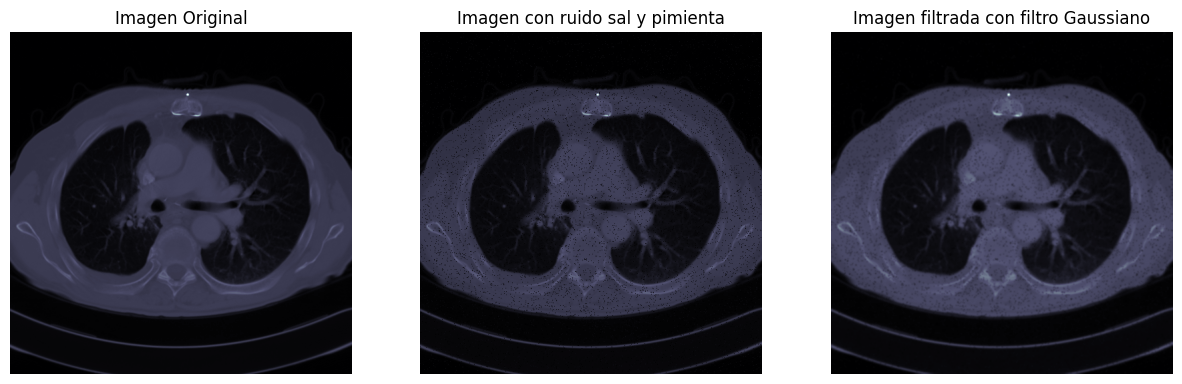

In [ ]:
def add_salt_and_pepper_noise(image, salt_prob = 0.02, pepper_prob = 0.02):
  noisy_image = np.copy(image)
  # Agregar sal (pix blancos)
  num_salt = np.ceil(salt_prob * image.size)
  coords = [np.random.randint(0, i - 1, int(num_salt)) for i in image.shape]
  noisy_image[tuple(coords)] = 255

  # Agregar pimienta (pix negros)
  num_pepper = np.ceil(pepper_prob * image.size)
  coords = [np.random.randint(0, i - 1, int(num_pepper)) for i in image.shape]
  noisy_image[tuple(coords)] = 0

  return noisy_image

# Aplicar la función del ruido
noisy_ct_sp = add_salt_and_pepper_noise(ct, salt_prob = 0.02, pepper_prob = 0.02)

# Aplicar filtro Gaussiano
gaussian_filtered_sp = cv2.GaussianBlur(noisy_ct_sp, (5,5), sigmaX= 1)

# Normalización
ct_normalized = cv2.normalize(ct, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
noisy_ct_sp_normalized = cv2.normalize(noisy_ct_sp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
gaussian_filtered_sp_normalized = cv2.normalize(gaussian_filtered_sp, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Visualizar resultados
plt.figure(figsize=(15, 5))
# Imagen Original
plt.subplot(1, 3, 1)
plt.imshow(ct_normalized, cmap = 'bone')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(noisy_ct_sp_normalized, cmap = 'bone')
plt.title('Imagen con ruido sal y pimienta')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gaussian_filtered_sp_normalized, cmap = 'bone')
plt.title('Imagen filtrada con filtro Gaussiano')
plt.axis('off')

plt.show()

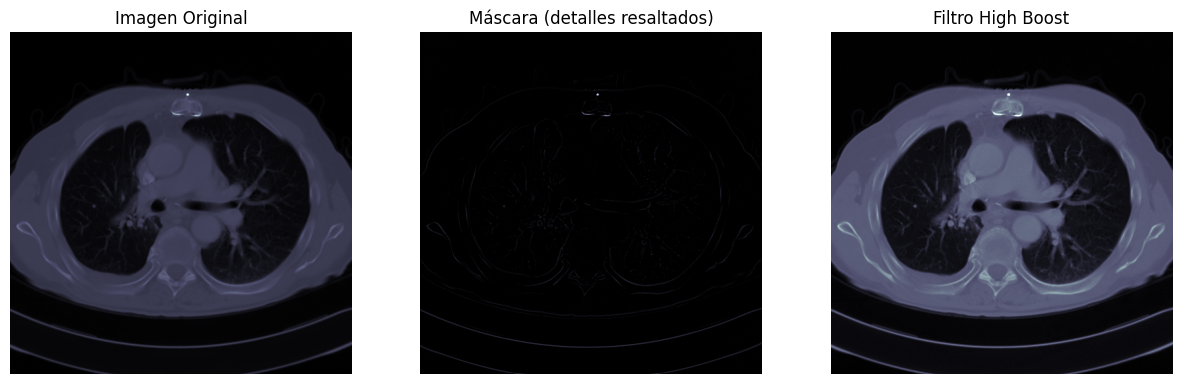

In [ ]:
# Filtro High-Boost

# Normalización de la imagen
ct_normalized = cv2.normalize(ct, None, alpha = 0, beta = 255, norm_type = cv2.NORM_MINMAX).astype(np.uint8)

# Suavidado de la imagen usando filtro gaussiano
blurred = cv2.GaussianBlur(ct_normalized, (5,5), 0)

# Crear una máscara (detalles de la imagen)
mask = cv2.subtract(ct_normalized, blurred)

# Aplicar filtro High-Boost
# High-Boost = k*Imagen Original +1 * Máscara
k = 1.5
high_boost = cv2.addWeighted(ct_normalized, k, mask, 1, 0)

# Visualizar resultados
plt.figure(figsize=(15, 5))
# Imagen Original
plt.subplot(1, 3, 1)
plt.imshow(ct, cmap = 'bone')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap = 'bone')
plt.title('Máscara (detalles resaltados)')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(high_boost, cmap = 'bone')
plt.title('Filtro High Boost')
plt.axis('off')

plt.show()


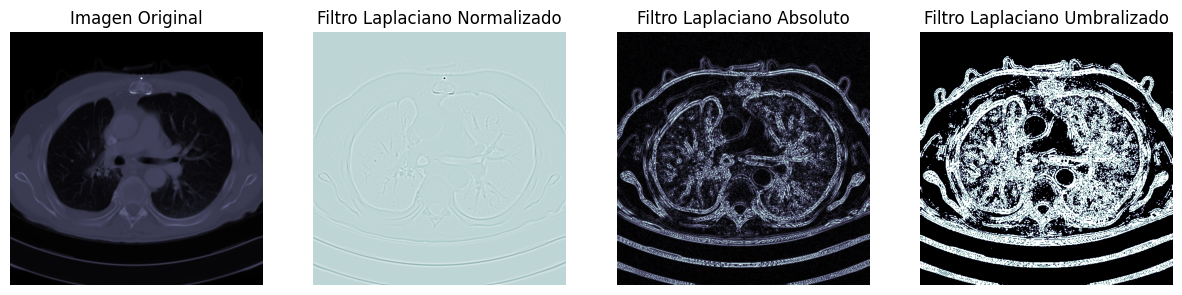

In [ ]:
# Filtro Laplaciano
import numpy as np
# 1. Aplicación del filtro Gaussiano
ct_smoothed = cv2.GaussianBlur(ct, (5,5), 0)

# 2. Aplicación del filtro Laplaciano
laplacian_filtered = cv2.Laplacian(ct_smoothed, cv2.CV_64F, ksize = 3)

# 3. Normalizar
laplacian_normalized = cv2.normalize(laplacian_filtered, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 4. Calcular el valor absoluto
laplacian_abs = np.abs(laplacian_filtered).astype(np.uint8)

# 5. Umbralización
_, laplacian_thresholded = cv2.threshold(laplacian_abs, 30, 255, cv2.THRESH_BINARY)

# Visualizar resultados
plt.figure(figsize=(15, 5))
# Imagen Original
plt.subplot(1, 4, 1)
plt.imshow(ct, cmap = 'bone')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(laplacian_normalized, cmap = 'bone')
plt.title('Filtro Laplaciano Normalizado')
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(laplacian_abs, cmap = 'bone')
plt.title('Filtro Laplaciano Absoluto')
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(laplacian_thresholded, cmap = 'bone')
plt.title('Filtro Laplaciano Umbralizado')
plt.axis('off')

plt.show()

In [ ]:
# Transformada de Fourier 2D
# Baja frecuencia:
# Alta frecuencia:
# Espectro de magnitudes:

# Aplicaciones:
# Filtrado en el dominio de la frecuencia
  # Filtro pasa bajas: eliminar frecuencias altas (detalles)
  # Filtro pasa altas: realzar los bordes al eliminar frecuencias bajas (fondos)
# Compresión de imágenes
# Corrección de artefactos: eliminar patrones repetitivos
# Análisis de patrones repetitivos

# Cuando se aplica la transformada de Fourier a una imagen:
  # El espectro resultante muestra las frecuencias en la imagen
  # Las frecuencias bajas ("suavidad") se encuentran cerca del centro
  # La frecuencias altas (bordes) están alejadas del centro

In [ ]:
# Transformada de Fourier 2D

# Transformada de Fourier 2D - Función
def fourier_transform(image):
  f = np.fft.fft2(image) # Calcular la transformada de Fourier 2D
  fshift = np.fft.fftshift(f) # Reorganizar el espectro de frecuencias para que el centro sea la frecuencia más baja
  magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) # Calcular el espectro de magnitudes
  return f, fshift, magnitude_spectrum

# Filtro Pasa Bajas

def low_pass_filter(fshift, radius = 50):
  rows, cols = fshift.shape
  crow, ccol = rows//2, cols//2
  mask = np.zeros((rows, cols), np.uint8)
  cv2.circle(mask, (ccol, crow), radius, 1, -1) # Crear una máscara cirular que retiene las freqs bajas
  return fshift*mask

# Filtro Pasa Altas
def high_pass_filter(fshift, radius = 50):
  rows, cols = fshift.shape
  crow, ccol = rows//2, cols//2
  mask = np.ones((rows, cols), np.uint8)
  cv2.circle(mask, (ccol, crow), radius, 0, -1) # Crear una máscara cirular inversa
  return fshift*mask

# Transformada inversa
def inverse_fourier(fshift_filtered):
  f_ishift = np.fft.ifftshift(fshift_filtered) # Revertir el desplazamiento
  img_back = np.fft.ifft2(f_ishift) # Transformada inversa para reconstruir
  img_back = np.abs(img_back) # Obtener la magnitud
  return img_back

# Normalizar la imagen
ct_normalized = cv2.normalize(ct, None, 0, 255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)

# Aplicar Transformada
f, fshift, magnitude_spectrum = fourier_transform(ct_normalized)

# Filtros
fshift_low = low_pass_filter(fshift, radius=50)
fshift_high = high_pass_filter(fshift, radius=50)

# Reconstrucción
low_pass_result = inverse_fourier(fshift_low)
high_pass_result = inverse_fourier(fshift_high)

(-0.5, 511.5, 511.5, -0.5)

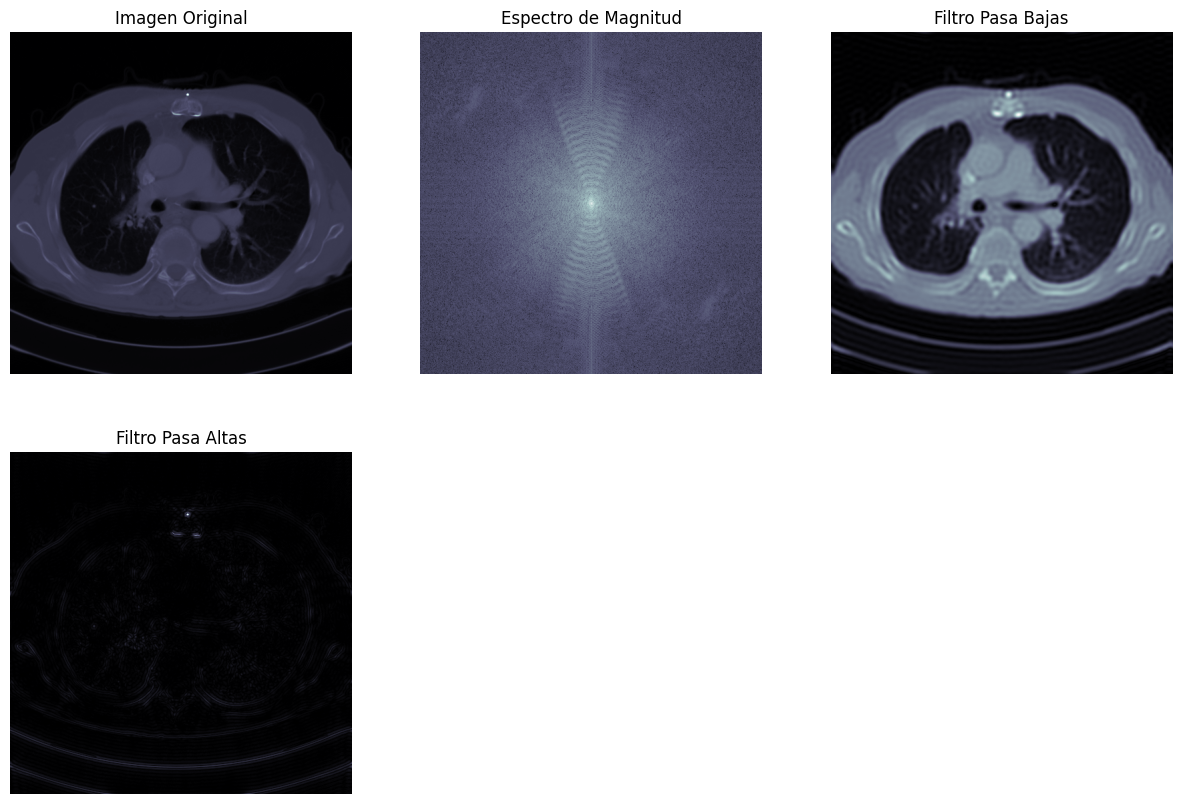

In [ ]:
# Visualizar resultados
plt.figure(figsize=(15, 10))
# Imagen Original
plt.subplot(2, 3, 1)
plt.imshow(ct_normalized, cmap = 'bone')
plt.title('Imagen Original')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(magnitude_spectrum, cmap = 'bone')
plt.title('Espectro de Magnitud')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(low_pass_result, cmap = 'bone')
plt.title('Filtro Pasa Bajas')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(high_pass_result, cmap = 'bone')
plt.title('Filtro Pasa Altas')
plt.axis('off')

In [ ]:
# Código Extra
def load_and_normalize_image(image):
  normalized_image = cv2.normalize(image, None, 0, 255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)
  return normalized_image

def fourier_transform(image):
  f = np.fft.fft2(image) # Calcular la transformada de Fourier 2D
  fshift = np.fft.fftshift(f) # Reorganizar el espectro de frecuencias para que el centro sea la frecuencia más baja
  magnitude_spectrum = 20 * np.log(np.abs(fshift) + 1) # Calcular el espectro de magnitudes
  return f, fshift, magnitude_spectrum

# Filtro Pasa Bajas
def low_pass_filter(fshift, radius):
  rows, cols = fshift.shape
  crow, ccol = rows//2, cols//2
  mask = np.zeros((rows, cols), np.uint8)
  cv2.circle(mask, (ccol, crow), radius, 1, -1) # Crear una máscara cirular que retiene las freqs bajas
  return fshift*mask

# Filtro Pasa Altas
def high_pass_filter(fshift, radius):
  rows, cols = fshift.shape
  crow, ccol = rows//2, cols//2
  mask = np.ones((rows, cols), np.uint8)
  cv2.circle(mask, (ccol, crow), radius, 0, -1) # Crear una máscara cirular inversa
  return fshift*mask

# Transformada inversa
def inverse_fourier(fshift_filtered):
  f_ishift = np.fft.ifftshift(fshift_filtered) # Revertir el desplazamiento
  img_back = np.fft.ifft2(f_ishift) # Transformada inversa para reconstruir
  img_back = np.abs(img_back) # Obtener la magnitud
  return img_back

# Filtro Canny
def apply_canny(image, threshold1, threshold2):
  return cv2.Canny(image, threshold1, threshold2)

# Visualización
def visualize_results(ct_normalized, magnitude_spectrum, low_pass_result, high_pass_result, canny_result):
  plt.figure(figsize=(15, 10))
  # Imagen Original
  plt.subplot(2, 3, 1)
  plt.imshow(ct_normalized, cmap = 'bone')
  plt.title('Imagen Original')
  plt.axis('off')

  plt.subplot(2, 3, 2)
  plt.imshow(magnitude_spectrum, cmap = 'bone')
  plt.title('Espectro de Magnitud')
  plt.axis('off')

  plt.subplot(2, 3, 3)
  plt.imshow(low_pass_result, cmap = 'bone')
  plt.title('Filtro Pasa Bajas')
  plt.axis('off')

  plt.subplot(2, 3, 4)
  plt.imshow(high_pass_result, cmap = 'bone')
  plt.title('Filtro Pasa Altas')
  plt.axis('off')

  plt.subplot(2, 3, 5)
  plt.imshow(canny_result, cmap = 'bone')
  plt.title('Filtro Canny')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

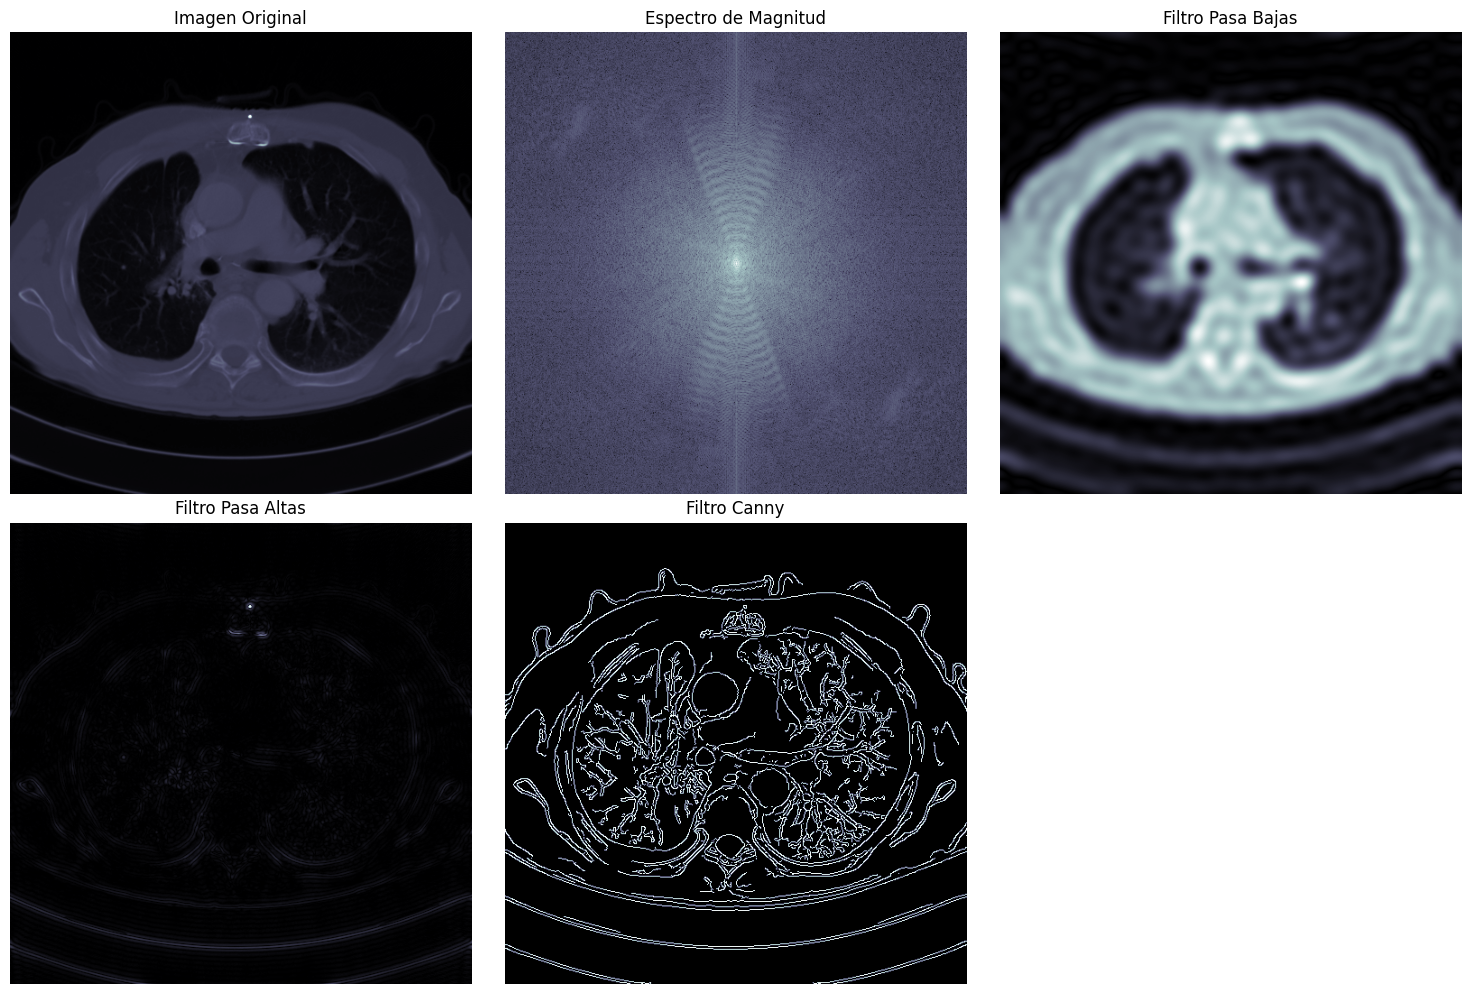

In [ ]:
def main(ct_image):
  # Normalización
  ct_normalized = load_and_normalize_image(ct_image)

  # Fourier
  f, fshift, magnitude_spectrum = fourier_transform(ct_normalized)

  # Parámetros ajustables
  radius_low = 20
  radius_high = 50
  threshold1 = 10
  threshold2 =30

  # Filtros
  fshift_low = low_pass_filter(fshift, radius_low)
  fshift_high = high_pass_filter(fshift, radius_high)

  # Reconstrucción
  low_pass_result = inverse_fourier(fshift_low)
  high_pass_result = inverse_fourier(fshift_high)

  # Canny
  canny_result = apply_canny(ct_normalized, threshold1, threshold2)

  # Visualización
  visualize_results(ct_normalized, magnitude_spectrum, low_pass_result, high_pass_result, canny_result)
main(ct)